## Preprocessing

In [1]:
import subprocess
subprocess.run(["pip", "install", "nltk", "scikit-learn", "pandas", "numpy", "matplotlib", "seaborn"], 
               capture_output=True)

CompletedProcess(args=['pip', 'install', 'nltk', 'scikit-learn', 'pandas', 'numpy', 'matplotlib', 'seaborn'], returncode=0, stdout=b'Requirement already satisfied: nltk in C:\\Users\\DEVANSHI\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python311\\site-packages (3.9.2)\r\nRequirement already satisfied: scikit-learn in C:\\Users\\DEVANSHI\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python311\\site-packages (1.7.2)\r\nRequirement already satisfied: pandas in C:\\Users\\DEVANSHI\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python311\\site-packages (2.3.2)\r\nRequirement already satisfied: numpy in C:\\Users\\DEVANSHI\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python311\\site-packages (2.4.6)\r\nRequirement already satisfied: matplotlib in C:\

In [2]:
import pandas as pd           # dataframes, loading CSV
import numpy as np            # numerical operations
import re                     # regex for text cleaning
import nltk                   # NLP toolkit
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# downloading nltk resources
nltk.download('stopwords')    # list of common words to remove (the, is, at...)
nltk.download('punkt')        # sentence/word tokenizer model
nltk.download('punkt_tab')    # updated tokenizer tables
nltk.download('wordnet')      # lemmatization dictionary

print("all imports done")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DEVANSHI\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\DEVANSHI\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\DEVANSHI\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\DEVANSHI\AppData\Roaming\nltk_data...


all imports done


[nltk_data]   Package wordnet is already up-to-date!


In [3]:
import pandas as pd

df = pd.read_csv("medquad-dataset.csv")  

print("shape:", df.shape)
print("columns:", df.columns.tolist())
print("\nfirst row:")
print(df.iloc[0])

shape: (16412, 4)
columns: ['question', 'answer', 'source', 'focus_area']

first row:
question                               What is (are) Glaucoma ?
answer        Glaucoma is a group of diseases that can damag...
source                                          NIHSeniorHealth
focus_area                                             Glaucoma
Name: 0, dtype: object


In [4]:
# eda
print(df.describe())

print(df.notnull().sum())

print(df.dtypes)             


print(df['source'].value_counts()) 

for q in df['question'].sample(5, random_state=42):
    print("-", q)

                                question  \
count                              16412   
unique                             14984   
top     What causes Causes of Diabetes ?   
freq                                  20   

                                                   answer source  \
count                                               16407  16412   
unique                                              15817      9   
top     This condition is inherited in an autosomal re...    GHR   
freq                                                  348   5430   

           focus_area  
count           16398  
unique           5126  
top     Breast Cancer  
freq               53  
question      16412
answer        16407
source        16412
focus_area    16398
dtype: int64
question      object
answer        object
source        object
focus_area    object
dtype: object
source
GHR                  5430
GARD                 5394
NIDDK                1192
NINDS                1088
MPlusHealthTopic

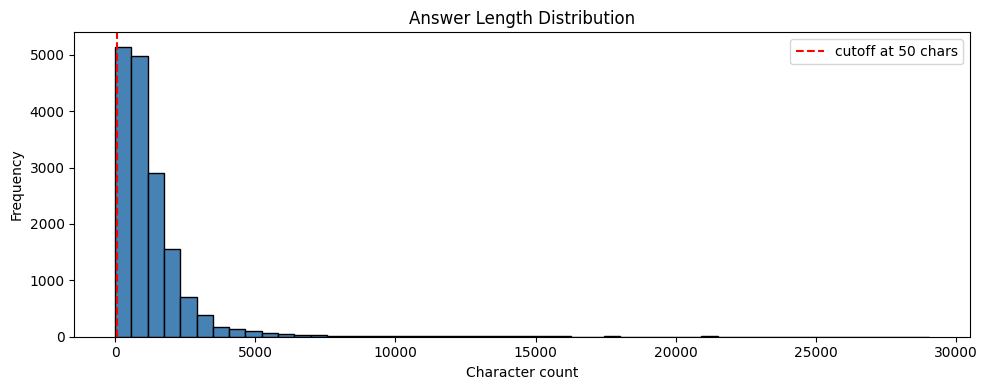

answers under 50 chars: 35
avg answer length: 1303 chars


In [5]:
# understanding how long answers are
# important because very short answers are useless for retrieval

df['answer_len'] = df['answer'].fillna('').apply(len)

plt.figure(figsize=(10, 4))
plt.hist(df['answer_len'], bins=50, color='steelblue', edgecolor='black')
plt.title('Answer Length Distribution')
plt.xlabel('Character count')
plt.ylabel('Frequency')
plt.axvline(50, color='red', linestyle='--', label='cutoff at 50 chars')
plt.legend()
plt.tight_layout()
plt.show()

print(f"answers under 50 chars: {(df['answer_len'] < 50).sum()}")
print(f"avg answer length: {df['answer_len'].mean():.0f} chars")

In [6]:
before  = len(df)
df = df.dropna(subset=['answer']).reset_index(drop=True)

df['focus_area']=df['focus_area'].fillna('Unknown')

df = df.drop(columns=['answer_len'])

print(f"dropped {before-len(df)} rows")
print (f"shape now: {df.shape}")

dropped 5 rows
shape now: (16407, 4)


intent distribution:
intent
general_info       10995
symptom_query       2936
treatment_query     2476
Name: count, dtype: int64


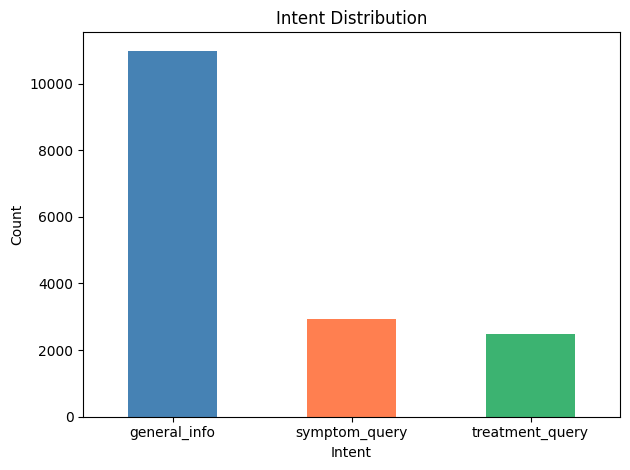

In [7]:
# we need labels for intent classification (phase 2)
# 3 classes: symptom_query, treatment_query, general_info
# using keyword matching on the question text
# this is rule-based labeling, not ML yet

def assign_intent(question):
    q = question.lower()   # lowercase for consistent matching
    
    if any(w in q for w in ['symptom', 'sign', 'feel', 'pain', 'ache', 'fever', 'cough']):
        return 'symptom_query'
    # any() returns True if at least one keyword found in question
    
    elif any(w in q for w in ['treat', 'cure', 'medication', 'drug', 'therapy', 'medicine', 'dose']):
        return 'treatment_query'
    
    else:
        return 'general_info'

df['intent'] = df['question'].apply(assign_intent)
# apply() runs assign_intent on every row in the question column

print("intent distribution:")
print(df['intent'].value_counts())

# visualize
df['intent'].value_counts().plot(kind='bar', color=['steelblue','coral','mediumseagreen'])
plt.title('Intent Distribution')
plt.xlabel('Intent')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [8]:
# this is the core cleaning function
# applied separately to questions and answers

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

def clean_text(text):
    text = str(text)                              # convert to string in case of any float/NaN slipping through
    text = text.lower()                           # HELLO WORLD -> hello world
    text = re.sub(r'http\S+|www\S+', '', text)   # remove URLs
    text = re.sub(r'<[^>]+>', '', text)           # remove HTML tags like <b>, <p>
    text = re.sub(r'\[.*?\]', '', text)           # remove [bracketed content]
    text = re.sub(r'[^a-z0-9\s\-]', '', text)    # remove special chars, keep hyphen
    text = re.sub(r'\s+', ' ', text).strip()      # collapse multiple spaces into one
    return text

# quick test
sample = "What is <b>Diabetes</b>? See https://nih.gov for [more info]!!!"
print("before:", sample)
print("after:", clean_text(sample))

before: What is <b>Diabetes</b>? See https://nih.gov for [more info]!!!
after: what is diabetes see for


In [9]:
lemmatizer = WordNetLemmatizer()
# lemmatizer reduces words to root form
# running -> run, diseases -> disease, treatments -> treatment

stop_words = set(stopwords.words('english'))
# set of ~180 common english words (the, is, at, which, on...)
# set() makes lookup O(1) instead of O(n)

# keeping medically important words that nltk removes by default
stop_words -= {'no', 'not', 'nor', 'never', 'without', 'more', 'less', 'above', 'below'}
# -= removes these words from stop_words set
# "no fever" vs "fever" mean very different things medically

def preprocess_text(text):
    cleaned = clean_text(text)              # apply cleaning first
    tokens = word_tokenize(cleaned)         # split into list of words
    tokens = [
        lemmatizer.lemmatize(t)             # reduce to root form
        for t in tokens
        if t not in stop_words              # skip stopwords
        and len(t) > 2                      # skip very short tokens like 'a', 'to'
    ]
    return ' '.join(tokens)                 # join back into a string

# test it
sample = "What are the treatments for high blood pressure and diabetes?"
print("original:", sample)
print("processed:", preprocess_text(sample))

original: What are the treatments for high blood pressure and diabetes?
processed: treatment high blood pressure diabetes


In [10]:
# applying to the full dataframe
# question_clean = just cleaned (used for display)
# question_processed = cleaned + tokenized + lemmatized (used for ML)
# answer_clean = just cleaned (used for display in chatbot response)
# answer is NOT lemmatized because we want readable answers returned to user

print("preprocessing questions...")
df['question_clean'] = df['question'].apply(clean_text)
df['question_processed'] = df['question'].apply(preprocess_text)

print("cleaning answers...")
df['answer_clean'] = df['answer'].apply(clean_text)

# remove duplicate questions
before = len(df)
df = df.drop_duplicates(subset=['question_clean']).reset_index(drop=True)
print(f"removed {before - len(df)} duplicates")

# remove rows where answer is too short to be useful
df = df[df['answer_clean'].str.len() > 50].reset_index(drop=True)

print(f"final shape: {df.shape}")
print("\nsample processed row:")
print("Q original :", df['question'][0])
print("Q processed:", df['question_processed'][0])
print("intent     :", df['intent'][0])

# save
df.to_csv('medquad_preprocessed.csv', index=False)
print("\nsaved as medquad_preprocessed.csv")

preprocessing questions...
cleaning answers...
removed 2067 duplicates
final shape: (14302, 8)

sample processed row:
Q original : What is (are) Glaucoma ?
Q processed: glaucoma
intent     : general_info

saved as medquad_preprocessed.csv


## TF-IDF Vectorisation

In [11]:
# starting fresh from saved file
# always reload from CSV at the start of a new phase
# so each phase is independently runnable

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import joblib
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('medquad_preprocessed.csv')
print("loaded:", df.shape)
print(df['intent'].value_counts())

loaded: (14302, 8)
intent
general_info       9440
symptom_query      2817
treatment_query    2045
Name: count, dtype: int64


In [12]:
# X = input features (the processed question text)
# y = labels (intent classes)
# this is standard supervised learning setup

X = df['question_processed']   # preprocessed text, what the model learns from
y = df['intent']               # target labels: symptom_query / treatment_query / general_info

print("X sample:", X[0])
print("y sample:", y[0])
print("\nclass distribution:")
print(y.value_counts())
print("\ntotal samples:", len(X))

X sample: glaucoma
y sample: general_info

class distribution:
intent
general_info       9440
symptom_query      2817
treatment_query    2045
Name: count, dtype: int64

total samples: 14302


In [13]:
# splitting data into training set and test set
# 80% train, 20% test
# stratify=y ensures class distribution is preserved in both splits
# e.g. if 20% of data is symptom_query, both train and test will have ~20% symptom_query

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 20% goes to test
    random_state=42,      # fixed seed for reproducibility
    stratify=y            # preserve class balance
)

print(f"train size: {len(X_train)}")
print(f"test size : {len(X_test)}")
print("\ntrain intent distribution:")
print(y_train.value_counts())

train size: 11441
test size : 2861

train intent distribution:
intent
general_info       7552
symptom_query      2253
treatment_query    1636
Name: count, dtype: int64


In [16]:
# TF-IDF converts text into numerical vectors
# TF = term frequency (how often a word appears in this doc)
# IDF = inverse document frequency (penalizes words common across ALL docs)
# result: rare but important words get higher scores

tfidf = TfidfVectorizer(
    max_features=5000,    # keep only top 5000 words by frequency
    ngram_range=(1, 2),   # use single words AND bigrams (e.g. "chest pain" as one feature)
    min_df=2,             # ignore words that appear in fewer than 2 documents
    sublinear_tf=True     # apply log normalization to term frequency, reduces impact of very frequent terms
)

# replace NaN with empty string
X_train = X_train.fillna("")
X_test = X_test.fillna("")
# fit on train only — never fit on test, that would be data leakage
X_train_tfidf = tfidf.fit_transform(X_train)
# fit_transform: learns vocabulary from train data AND transforms it

X_test_tfidf = tfidf.transform(X_test)
# transform only: uses vocabulary learned from train, applies to test

print("train matrix shape:", X_train_tfidf.shape)
# shape = (num_samples, num_features) = (11441, 5000)
print("test matrix shape:", X_test_tfidf.shape)

# peek at some feature names
print("\nsample TF-IDF features:")
print(tfidf.get_feature_names_out()[100:120])

train matrix shape: (11441, 5000)
test matrix shape: (2861, 5000)

sample TF-IDF features:
['acromicric' 'acromicric dysplasia' 'actin' 'actin accumulation'
 'activated' 'activated pi3k' 'acuta' 'acute' 'acute febrile'
 'acute intermittent' 'acute lymphoblastic' 'acute myeloid'
 'acute promyelocytic' 'acyl' 'acyl coa' 'acyl coenzyme' 'acylcarnitine'
 'acylcarnitine translocase' 'adams' 'adams oliver']


In [17]:
# training 3 classifiers from your syllabus section 3
# Logistic Regression, Naive Bayes, SVM
# comparing all three is good practice and looks great in a project

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0),
    # C = regularization strength, higher C = less regularization
    
    'Naive Bayes': MultinomialNB(alpha=0.1),
    # alpha = smoothing parameter, handles unseen words
    # MultinomialNB works well with TF-IDF/count vectors
    
    'Linear SVM': LinearSVC(max_iter=1000, C=1.0)
    # LinearSVC = SVM with linear kernel, fast and effective for text
}

results = {}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)          # train
    score = model.score(X_test_tfidf, y_test)  # accuracy on test set
    results[name] = score
    print(f"{name}: {score:.4f}")

Logistic Regression: 0.9930
Naive Bayes: 0.8319
Linear SVM: 0.9983


=== CLASSIFICATION REPORT ===
                 precision    recall  f1-score   support

   general_info       0.99      1.00      1.00      1888
  symptom_query       1.00      0.98      0.99       564
treatment_query       0.99      0.99      0.99       409

       accuracy                           0.99      2861
      macro avg       0.99      0.99      0.99      2861
   weighted avg       0.99      0.99      0.99      2861

=== CONFUSION MATRIX ===


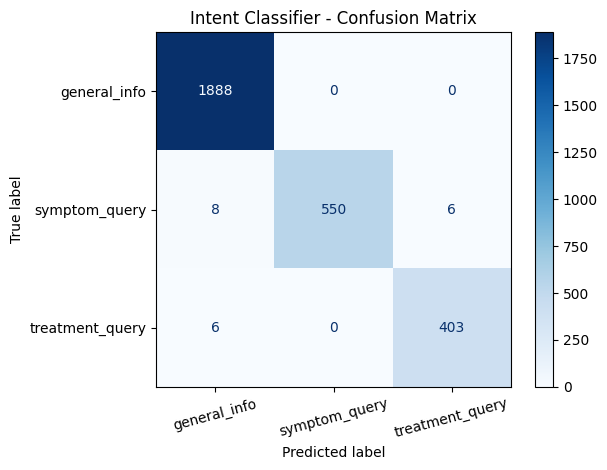

In [18]:
# logistic regression usually wins on this type of data
# let's do full evaluation on it

best_model = models['Logistic Regression']
y_pred = best_model.predict(X_test_tfidf)

print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred))
# shows precision, recall, F1 for each class
# precision = of all predicted symptom_query, how many were actually symptom_query
# recall = of all actual symptom_query, how many did we correctly catch
# F1 = harmonic mean of precision and recall

print("=== CONFUSION MATRIX ===")
cm = confusion_matrix(y_test, y_pred, labels=best_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap='Blues')
plt.title('Intent Classifier - Confusion Matrix')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [19]:
# cross validation = more reliable than single train/test split
# splits data into 5 folds, trains 5 times, averages the scores
# gives you a better estimate of real-world performance

cv_scores = cross_val_score(
    LogisticRegression(max_iter=1000),
    X_train_tfidf,
    y_train,
    cv=5,           # 5-fold cross validation
    scoring='f1_weighted'   # weighted F1 accounts for class imbalance
)

print("CV scores:", cv_scores)
print(f"mean F1: {cv_scores.mean():.4f}")
print(f"std dev: {cv_scores.std():.4f}")
# low std dev means model is consistent, not just getting lucky on one split

CV scores: [0.98945884 0.9881357  0.99342751 0.98769973 0.99078801]
mean F1: 0.9899
std dev: 0.0021


In [20]:
# saving both the vectorizer and the model
# BOTH need to be saved — vectorizer learned the vocabulary
# when a new user query comes in, it must be transformed using the SAME vocabulary

joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
joblib.dump(best_model, 'intent_classifier.pkl')

print("saved tfidf_vectorizer.pkl")
print("saved intent_classifier.pkl")

# quick load test to verify
loaded_vectorizer = joblib.load('tfidf_vectorizer.pkl')
loaded_model = joblib.load('intent_classifier.pkl')

test_query = "what are the symptoms of diabetes"
vec = loaded_vectorizer.transform([test_query])
pred = loaded_model.predict(vec)
print(f"\ntest query: '{test_query}'")
print(f"predicted intent: {pred[0]}")

saved tfidf_vectorizer.pkl
saved intent_classifier.pkl

test query: 'what are the symptoms of diabetes'
predicted intent: general_info


## Retrieval engine

In [22]:
# retrieval = finding the most relevant answer from our 14k QA pairs
# approach:
# 1. TF-IDF vectorize ALL questions in the dataset
# 2. vectorize the user's query the same way
# 3. use cosine similarity to find the closest matching question

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# ---------------------------
# CLEAN THE DATA FIRST
# ---------------------------

# remove rows where processed question is missing
df = df.dropna(subset=['question_processed'])

# convert everything to string
df['question_processed'] = df['question_processed'].astype(str)

# remove empty strings if any
df = df[df['question_processed'].str.strip() != ""]

print("Total usable questions:", len(df))

# ---------------------------
# BUILD RETRIEVAL VECTORIZER
# ---------------------------

# separate vectorizer for retrieval
# retrieval needs broader vocabulary coverage
# compared to intent classification

retrieval_vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=1,
    sublinear_tf=True
)

# fit on ALL processed questions
# because retrieval searches the full dataset

question_vectors = retrieval_vectorizer.fit_transform(
    df['question_processed']
)

print("question vectors shape:", question_vectors.shape)

# example expected output:
# (14302, 10000)

Total usable questions: 14301
question vectors shape: (14301, 10000)


In [23]:
def retrieve_answer(user_query, top_k=3):
    """
    takes a raw user query, returns top_k most similar QA pairs
    along with their similarity scores
    """
    # preprocess the query the SAME way we preprocessed the dataset
    # critical: if preprocessing differs, vectors won't be comparable
    query_processed = preprocess_text(user_query)
    
    # transform query into the same vector space as our questions
    query_vector = retrieval_vectorizer.transform([query_processed])
    
    # cosine similarity between query and ALL questions in dataset
    # returns array of shape (1, 14302) — one score per question
    similarities = cosine_similarity(query_vector, question_vectors).flatten()
    # flatten() converts (1, 14302) to (14302,) for easier indexing
    
    # get indices of top_k highest similarity scores
    top_indices = similarities.argsort()[-top_k:][::-1]
    # argsort() sorts ascending, [-top_k:] takes last k (highest), [::-1] reverses to descending
    
    results = []
    for idx in top_indices:
        results.append({
            'question': df.iloc[idx]['question'],
            'answer': df.iloc[idx]['answer_clean'],
            'focus_area': df.iloc[idx]['focus_area'],
            'intent': df.iloc[idx]['intent'],
            'similarity': similarities[idx],
            'index': idx
        })
    
    return results

# test it
test_query = "what causes high blood pressure"
results = retrieve_answer(test_query, top_k=3)

for i, r in enumerate(results):
    print(f"\n--- Result {i+1} (similarity: {r['similarity']:.4f}) ---")
    print(f"Matched Q: {r['question']}")
    print(f"Focus area: {r['focus_area']}")
    print(f"Answer preview: {r['answer'][:150]}...")


--- Result 1 (similarity: 1.0000) ---
Matched Q: What causes High Blood Pressure ?
Focus area: High Blood Pressure
Answer preview: changes in body functions researchers continue to study how various changes in normal body functions cause high blood pressure the key functions affec...

--- Result 2 (similarity: 0.8500) ---
Matched Q: What is (are) High Blood Pressure ?
Focus area: High Blood Pressure
Answer preview: high blood pressure is a common disease in which blood flows through blood vessels arteries at higher than normal pressures what is blood pressure blo...

--- Result 3 (similarity: 0.8136) ---
Matched Q: Who is at risk for High Blood Pressure? ?
Focus area: High Blood Pressure
Answer preview: not a normal part of aging nearly 1 in 3 american adults have high blood pressure many people get high blood pressure as they get older however gettin...


In [24]:
# testing across different phrasings and intents to see how robust retrieval is

test_queries = [
    "what are the symptoms of diabetes",
    "how is asthma treated",
    "tell me about glaucoma",
    "is high blood pressure dangerous",
    "medication for arthritis pain"
]

for q in test_queries:
    results = retrieve_answer(q, top_k=1)
    top = results[0]
    print(f"Query: {q}")
    print(f"  -> Matched: {top['question']} (sim: {top['similarity']:.3f})")
    print()

Query: what are the symptoms of diabetes
  -> Matched: What are the symptoms of Diabetes ? (sim: 1.000)

Query: how is asthma treated
  -> Matched: What is (are) Asthma ? (sim: 0.713)

Query: tell me about glaucoma
  -> Matched: What is (are) Glaucoma ? (sim: 1.000)

Query: is high blood pressure dangerous
  -> Matched: What is (are) High Blood Pressure ? (sim: 1.000)

Query: medication for arthritis pain
  -> Matched: What is (are) Arthritis ? (sim: 0.514)



In [39]:
    # important for a real chatbot: what happens when the query doesn't match anything well?
    # we need a confidence threshold

    def retrieve_with_threshold(user_query, top_k=3, threshold=0.45):
        results = retrieve_answer(user_query, top_k=top_k)
        
        best_score = results[0]['similarity']
        
        if best_score < threshold:
            return {
                'status': 'no_match',
                'message': "I couldn't find a confident answer to that in my medical database. Try rephrasing, or consult a healthcare professional.",
                'best_attempt': results[0],   # still show closest match for reference
            }
        else:
            return {
                'status': 'match_found',
                'results': results
            }



In [40]:
# test with an irrelevant/out-of-domain query
weird_query = "what is the best pizza topping"
output = retrieve_with_threshold(weird_query)
print("Status:", output['status'])
if output['status'] == 'no_match':
    print("Message:", output['message'])
    print("Closest attempt (low confidence):", output['best_attempt']['question'], 
          f"(sim: {output['best_attempt']['similarity']:.3f})")

print("\n---\n")

Status: no_match
Message: I couldn't find a confident answer to that in my medical database. Try rephrasing, or consult a healthcare professional.
Closest attempt (low confidence): What is (are) Best vitelliform macular dystrophy ? (sim: 0.431)

---



In [41]:
# test with a real medical query
real_query = "what are signs of a heart attack"
output = retrieve_with_threshold(real_query)
print("Status:", output['status'])
if output['status'] == 'match_found':
    print("Top match:", output['results'][0]['question'])

Status: match_found
Top match: What is (are) Heart Attack ?


In [42]:
import joblib

joblib.dump(retrieval_vectorizer, 'retrieval_vectorizer.pkl')
joblib.dump(question_vectors, 'question_vectors.pkl')

# also save the dataframe itself, since retrieval needs to look up rows by index
df.to_pickle('cliniq_data.pkl')

print("saved retrieval_vectorizer.pkl")
print("saved question_vectors.pkl")
print("saved cliniq_data.pkl")

saved retrieval_vectorizer.pkl
saved question_vectors.pkl
saved cliniq_data.pkl


## The explainability layer

In [ ]:
#USP. the goal: show WHY a particular answer was retrieved
# two components:
#   1. keyword overlap — which words in the query matched the retrieved question/answer
#   2. confidence score — already have this from cosine similarity

# we'll extract the TF-IDF weighted terms that contributed most to the match


In [43]:
def get_matched_keywords(user_query, matched_question_idx, top_n=5):
    """
    finds which words from the user query overlap with the matched question,
    ranked by their TF-IDF importance
    """
    query_processed = preprocess_text(user_query)
    query_tokens = set(query_processed.split())
    
    matched_question_processed = df.iloc[matched_question_idx]['question_processed']
    matched_tokens = set(matched_question_processed.split())
    
    # intersection = words present in both query and matched question
    overlap = query_tokens & matched_tokens
    
    if not overlap:
        return []
    
    # rank overlapping words by their TF-IDF score in the retrieval vectorizer
    # higher TF-IDF score = rarer, more medically significant word
    feature_names = retrieval_vectorizer.get_feature_names_out()
    vocab = {word: idx for idx, word in enumerate(feature_names)}
    
    query_vector = retrieval_vectorizer.transform([query_processed])
    query_array = query_vector.toarray()[0]
    
    scored_overlap = []
    for word in overlap:
        if word in vocab:
            score = query_array[vocab[word]]
            scored_overlap.append((word, score))
    
    # sort descending by score, take top_n
    scored_overlap.sort(key=lambda x: x[1], reverse=True)
    return scored_overlap[:top_n]

# test
test_query = "what are the symptoms of diabetes"
results = retrieve_answer(test_query, top_k=1)
matched_idx = results[0]['index']

keywords = get_matched_keywords(test_query, matched_idx)
print("Query:", test_query)
print("Matched question:", results[0]['question'])
print("\nMatched keywords (word, TF-IDF weight):")
for word, score in keywords:
    print(f"  {word}: {score:.4f}")

Query: what are the symptoms of diabetes
Matched question: What are the symptoms of Diabetes ?

Matched keywords (word, TF-IDF weight):
  diabetes: 0.5061
  symptom: 0.2415


In [44]:
# now we highlight where those matched keywords appear in the ANSWER itself
# this shows the user exactly which part of the answer is relevant to their query

def highlight_answer(answer_text, keywords):
    """
    wraps matched keywords in the answer with markers
    using **word** so it renders bold in markdown/streamlit
    """
    highlighted = answer_text
    keyword_list = [kw for kw, score in keywords]
    
    for kw in keyword_list:
        # use word boundaries so we don't match partial words
        # e.g. "pain" shouldn't match inside "painful" incorrectly mid-word
        pattern = r'\b(' + re.escape(kw) + r')\b'
        highlighted = re.sub(pattern, r'**\1**', highlighted, flags=re.IGNORECASE)
    
    return highlighted

import re

# test
test_query = "what are the symptoms of diabetes"
results = retrieve_answer(test_query, top_k=1)
matched_idx = results[0]['index']
keywords = get_matched_keywords(test_query, matched_idx)

answer = results[0]['answer']
highlighted = highlight_answer(answer, keywords)

print("ORIGINAL (first 300 chars):")
print(answer[:300])
print("\nHIGHLIGHTED (first 300 chars):")
print(highlighted[:300])

ORIGINAL (first 300 chars):
diabetes is often called a silent disease because it can cause serious complications even before you have symptoms symptoms can also be so mild that you dont notice them an estimated 8 million people in the united states have type 2 diabetes and dont know it according to 2012 estimates by the center

HIGHLIGHTED (first 300 chars):
**diabetes** is often called a silent disease because it can cause serious complications even before you have symptoms symptoms can also be so mild that you dont notice them an estimated 8 million people in the united states have type 2 **diabetes** and dont know it according to 2012 estimates by th


In [46]:
# aligning confidence bands with your tuned no-match threshold of 0.45
# anything below 0.45 isn't just "Low" — it's effectively "no match"

def confidence_label(similarity_score, no_match_threshold=0.45):
    if similarity_score < no_match_threshold:
        return "No reliable match", "🔴"
    elif similarity_score < 0.6:
        return "Medium", "🟡"
    else:
        return "High", "🟢"

# retest across queries
test_queries = [
    "what are the symptoms of diabetes",
    "how is asthma treated",
    "what is the best pizza topping"
]

for q in test_queries:
    results = retrieve_answer(q, top_k=1)
    score = results[0]['similarity']
    label, emoji = confidence_label(score)
    print(f"{emoji} {label} ({score:.3f}) — {q}")

🟢 High (1.000) — what are the symptoms of diabetes
🟢 High (0.713) — how is asthma treated
🔴 No reliable match (0.431) — what is the best pizza topping


 Full explainability wrapper

In [47]:
# this single function combines everything from phases 3 and 4:
# retrieval + threshold check + keywords + highlighting + confidence label
# this is what your Streamlit app will call directly

def get_explainable_answer(user_query, threshold=0.45):
    """
    full pipeline: query -> retrieval -> explainability -> structured response
    returns a dict ready to be displayed in the UI
    """
    results = retrieve_answer(user_query, top_k=3)
    best = results[0]
    score = best['similarity']
    label, emoji = confidence_label(score, threshold)
    
    if score < threshold:
        return {
            'status': 'no_match',
            'confidence_label': label,
            'confidence_emoji': emoji,
            'similarity': score,
            'message': "I couldn't find a confident answer to that in my medical database. Try rephrasing, or consult a healthcare professional.",
            'closest_question': best['question'],   # show for transparency even on no-match
        }
    
    # only compute keywords/highlighting when we have a real match
    keywords = get_matched_keywords(user_query, best['index'])
    highlighted_answer = highlight_answer(best['answer'], keywords)
    
    return {
        'status': 'match_found',
        'confidence_label': label,
        'confidence_emoji': emoji,
        'similarity': round(float(score), 4),
        'matched_question': best['question'],
        'focus_area': best['focus_area'],
        'intent': best['intent'],
        'answer': best['answer'],
        'answer_highlighted': highlighted_answer,
        'matched_keywords': [kw for kw, s in keywords],
        'alternative_matches': [
            {'question': r['question'], 'similarity': round(float(r['similarity']), 4)}
            for r in results[1:]   # show 2nd and 3rd matches as alternatives
        ]
    }

# test the full pipeline
test_query = "what causes chest pain"
output = get_explainable_answer(test_query)

print("STATUS:", output['status'])
print("CONFIDENCE:", output['confidence_emoji'], output['confidence_label'], f"({output['similarity']})")

if output['status'] == 'match_found':
    print("MATCHED QUESTION:", output['matched_question'])
    print("FOCUS AREA:", output['focus_area'])
    print("INTENT:", output['intent'])
    print("MATCHED KEYWORDS:", output['matched_keywords'])
    print("\nANSWER (highlighted, first 400 chars):")
    print(output['answer_highlighted'][:400])
    print("\nALTERNATIVE MATCHES:")
    for alt in output['alternative_matches']:
        print(f"  - {alt['question']} (sim: {alt['similarity']})")

STATUS: match_found
CONFIDENCE: 🟢 High (0.9434)
MATCHED QUESTION: What is (are) Chest Pain ?
FOCUS AREA: Chest Pain
INTENT: symptom_query
MATCHED KEYWORDS: ['chest', 'pain']

ANSWER (highlighted, first 400 chars):
having a **pain** in your **chest** can be scary it does not always mean that you are having a heart attack there can be many other causes including - other heart problems such as angina - panic attacks - digestive problems such as heartburn or esophagus disorders - sore muscles - lung diseases such as pneumonia pleurisy or pulmonary embolism - costochondritis - an inflammation of joints in your *

ALTERNATIVE MATCHES:
  - What is (are) Pain ? (sim: 0.547)
  - What is (are) Chest Injuries and Disorders ? (sim: 0.4915)


In [49]:
# stress testing the full pipeline before moving to streamlit
# good practice: test happy path, edge case, and failure case

edge_cases = [
    "what are the symptoms of diabetes",      # should match well
    "asdkjasdkj random gibberish",             # should be no_match
    "",                                          # empty string — does it crash?
    "PAIN",                                      # single word, all caps
    "what should I do if I have a fever and cough",  # should match treatment or symptom
]

for q in edge_cases:
    print(f"\n{'='*50}")
    print(f"QUERY: '{q}'")
    try:
        output = get_explainable_answer(q)
        print("STATUS:", output['status'])
        print("CONFIDENCE:", output.get('confidence_label'), output.get('similarity'))
    except Exception as e:
        print("ERROR:", e)


QUERY: 'what are the symptoms of diabetes'
STATUS: match_found
CONFIDENCE: High 1.0

QUERY: 'asdkjasdkj random gibberish'
STATUS: no_match
CONFIDENCE: No reliable match 0.0

QUERY: ''
STATUS: no_match
CONFIDENCE: No reliable match 0.0

QUERY: 'PAIN'
STATUS: match_found
CONFIDENCE: High 1.0

QUERY: 'what should I do if I have a fever and cough'
STATUS: match_found
CONFIDENCE: High 0.7918


Intent classifier

In [50]:
# right now intent classifier (phase 2) and retrieval (phase 3-4) are separate
# for the chatbot, every query should show its predicted intent too

intent_vectorizer = joblib.load('tfidf_vectorizer.pkl')
intent_model = joblib.load('intent_classifier.pkl')

def predict_intent(user_query):
    query_processed = preprocess_text(user_query)
    if not query_processed.strip():
        return 'unknown'
    vec = intent_vectorizer.transform([query_processed])
    return intent_model.predict(vec)[0]

# test
test_queries = [
    "what are the symptoms of diabetes",
    "how is asthma treated",
    "tell me about glaucoma"
]

for q in test_queries:
    print(f"{q} -> {predict_intent(q)}")

what are the symptoms of diabetes -> symptom_query
how is asthma treated -> general_info
tell me about glaucoma -> general_info


In [51]:
# this is the single function Streamlit app will call
# combines everything: intent prediction + retrieval + explainability

def cliniq_pipeline(user_query, threshold=0.45):
    if not user_query or not user_query.strip():
        return {'status': 'invalid_input', 'message': "Please enter a question."}
    
    predicted_intent = predict_intent(user_query)
    
    response = get_explainable_answer(user_query, threshold=threshold)
    response['predicted_intent'] = predicted_intent   # add live intent prediction
    
    return response

# full test
test_query = "what are the symptoms of diabetes"
output = cliniq_pipeline(test_query)

print("QUERY:", test_query)
print("STATUS:", output['status'])
print("PREDICTED INTENT:", output['predicted_intent'])
if output['status'] == 'match_found':
    print("CONFIDENCE:", output['confidence_emoji'], output['confidence_label'])
    print("MATCHED Q:", output['matched_question'])
    print("KEYWORDS:", output['matched_keywords'])

QUERY: what are the symptoms of diabetes
STATUS: match_found
PREDICTED INTENT: symptom_query
CONFIDENCE: 🟢 High
MATCHED Q: What are the symptoms of Diabetes ?
KEYWORDS: ['diabetes', 'symptom']
